# Анализ своевременности доставки заказов Olist

> Исследование сроков доставки, факторов опозданий и связи задержек с оценками покупателей.

**Период данных:** 2016–2018 годы  
**Объект анализа:** заказы бразильского маркетплейса Olist  
**Инструменты:** Python · pandas · NumPy · Matplotlib · Seaborn · SciPy

## Содержание

1. [Постановка задачи](#task)
2. [Описание и подготовка данных](#data)
3. [Качество данных и формирование выборки](#quality)
4. [Анализ сроков доставки](#delivery)
5. [Опоздания и оценки покупателей](#reviews)
6. [Факторы и динамика опозданий](#factors)
7. [Связь частоты и продолжительности опозданий](#correlation)
8. [Общие выводы и рекомендации](#conclusions)


<a id='task'></a>

## 1. Постановка задачи

Маркетплейс обрабатывает большое количество заказов, часть из которых доставляется позже обещанного срока. Задержки могут снижать удовлетворённость покупателей и негативно влиять на их готовность совершать повторные покупки.

**Цель анализа** — определить долю просроченных заказов, выяснить, при каких условиях чаще возникают задержки, и проверить их связь с оценками покупателей. На основании результатов можно предложить систему раннего контроля заказов, которые рискуют не уложиться в срок.


<a id='data'></a>

## 2. Описание и подготовка данных


Для анализа используется [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Датасет содержит информацию о заказах, оформленных в бразильском маркетплейсе в 2016–2018 годах. Данные разделены на несколько связанных таблиц.

В проекте используются:

- `olist_orders_dataset.csv` — статусы и даты жизненного цикла заказов;
- `olist_order_items_dataset.csv` — товары, продавцы, стоимость товаров и доставки;
- `olist_customers_dataset.csv` — города и штаты покупателей;
- `olist_sellers_dataset.csv` — города и штаты продавцов;
- `olist_order_reviews_dataset.csv` — оценки покупателей.

Главной является таблица заказов. По плановой и фактической датам доставки определяется факт опоздания. Остальные таблицы позволяют проверить связь задержек с регионом, параметрами заказа и оценкой покупателя.

Таблицы с платежами и географическими координатами не используются, поскольку напрямую не связаны с поставленной задачей.


In [9]:
import pandas as pd
from pathlib import Path

data_path = Path('dataset olist')

In [12]:
orders = pd.read_csv(data_path / 'olist_orders_dataset.csv')
order_items = pd.read_csv(data_path / 'olist_order_items_dataset.csv')
customers = pd.read_csv(data_path / 'olist_customers_dataset.csv')
sellers = pd.read_csv(data_path / 'olist_sellers_dataset.csv')
reviews = pd.read_csv(data_path / 'olist_order_reviews_dataset.csv')

In [14]:
tables = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'sellers': sellers,
    'reviews': reviews
}

table_info = pd.DataFrame([
    {
        'table': name,
        'rows': df.shape[0],
        'columns': df.shape[1]
    }
    for name, df in tables.items()
])

table_info

,table,rows,columns
0,orders,99441,8
1,order_items,112650,7
2,customers,99441,5
3,sellers,3095,4
4,reviews,99224,7


In [16]:
for name, df in tables.items():
    print(f'\nТаблица {name}:')
    print(df.columns.tolist())


Таблица orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Таблица order_items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Таблица customers:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Таблица sellers:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Таблица reviews:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


### 2.1. Связи между таблицами

Основной таблицей является `orders`, в которой одна строка соответствует одному заказу. Уникальным идентификатором заказа служит `order_id`.

Таблица `orders` связана с таблицей `customers` по полю `customer_id`. Информация о товарах присоединяется из таблицы `order_items` по полю `order_id`, а данные о продавцах - из таблицы `sellers` по полю `seller_id`. Отзывы покупателей связаны с заказами через `order_id`.

Связь между `orders` и `order_items` имеет тип «один ко многим», поскольку один заказ может содержать несколько товаров. По этой причине перед объединением данных необходимо проверить уникальность ключей и количество строк, соответствующих одному заказу.

Поле `customer_id` относится к конкретному заказу, а `customer_unique_id` позволяет определить одного и того же покупателя в разных заказах.


In [18]:
key_check = pd.DataFrame({
    'table': [
        'orders',
        'order_items',
        'customers',
        'sellers',
        'reviews'
    ],
    'key': [
        'order_id',
        'order_id',
        'customer_id',
        'seller_id',
        'order_id'
    ],
    'rows': [
        len(orders),
        len(order_items),
        len(customers),
        len(sellers),
        len(reviews)
    ],
    'unique_keys': [
        orders['order_id'].nunique(),
        order_items['order_id'].nunique(),
        customers['customer_id'].nunique(),
        sellers['seller_id'].nunique(),
        reviews['order_id'].nunique()
    ]
})

key_check['duplicates'] = (
    key_check['rows'] - key_check['unique_keys']
)

key_check

,table,key,rows,unique_keys,duplicates
0,orders,order_id,99441,99441,0
1,order_items,order_id,112650,98666,13984
2,customers,customer_id,99441,99441,0
3,sellers,seller_id,3095,3095,0
4,reviews,order_id,99224,98673,551


In [23]:
review_counts = reviews['order_id'].value_counts()

review_duplicates = review_counts[review_counts > 1]

print('Заказов с несколькими отзывами:', len(review_duplicates))
print('Дополнительных строк:', (review_duplicates - 1).sum())

review_duplicates.head()

Заказов с несколькими отзывами: 547
Дополнительных строк: 551


order_id
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
5cb890a68b91b6158d69257e4e2bc359    2
Name: count, dtype: int64

In [27]:
duplicate_reviews = (
    reviews[
        reviews.duplicated(subset='order_id', keep=False)
    ]
    .sort_values('order_id')
)

duplicate_reviews.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30


In [24]:
different_scores = (
    duplicate_reviews
    .groupby('order_id')['review_score']
    .nunique()
)

print(
    'Заказов с разными оценками:',
    (different_scores > 1).sum()
)

Заказов с разными оценками: 202


In [26]:
orders_with_different_scores = different_scores[
    different_scores > 1
].index

duplicate_reviews[
    duplicate_reviews['order_id'].isin(
        orders_with_different_scores
    )
].head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19


In [29]:
reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp'],
    errors='coerce'
)

print(
    'Пропусков в дате ответа:',
    reviews['review_answer_timestamp'].isna().sum()
)

# пропусков нет, поэтому создаём таблицу с одним последним отзывом на заказ
reviews_clean = (
    reviews
    .sort_values('review_answer_timestamp')
    .drop_duplicates(subset='order_id', keep='last')
)

# проверяем результат
print('Строк до обработки:', len(reviews))
print('Строк после обработки:', len(reviews_clean))
print(
    'Повторяющихся order_id:',
    reviews_clean['order_id'].duplicated().sum()
)

Пропусков в дате ответа: 0
Строк до обработки: 99224
Строк после обработки: 98673
Повторяющихся order_id: 0


### 2.2. Обработка повторяющихся отзывов

В таблице отзывов обнаружено 547 заказов, которым соответствует несколько записей. У 202 таких заказов оценки различаются, поэтому случайное удаление повторений может привести к потере более актуальной оценки.

Для дальнейшего анализа было принято решение оставить последний отзыв по времени его заполнения. После обработки каждому заказу соответствует не более одного отзыва.


In [33]:
order_items_agg = (
    order_items
    .groupby('order_id')
    .agg(
        items_count=('order_item_id', 'count'),
        sellers_count=('seller_id', 'nunique'),
        order_price=('price', 'sum'),
        freight_value=('freight_value', 'sum')
    )
    .reset_index()
)

order_items_agg.head()

,order_id,items_count,sellers_count,order_price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


In [34]:
print('Строк после агрегации:', len(order_items_agg))
print(
    'Повторяющихся order_id:',
    order_items_agg['order_id'].duplicated().sum()
)

Строк после агрегации: 98666
Повторяющихся order_id: 0


### 2.3. Агрегация товарных позиций

В таблице `order_items` одному заказу может соответствовать несколько строк, поскольку заказ способен содержать несколько товаров и товары разных продавцов. Удалять такие повторения нельзя, так как они являются отдельными товарными позициями.

Поэтому данные были агрегированы до уровня заказа. Для каждого заказа рассчитаны количество товарных позиций, количество уникальных продавцов, общая стоимость товаров и общая стоимость доставки. После агрегации каждому `order_id` соответствует одна строка.


In [37]:
orders_full = (
    orders
    .merge(
        customers,
        on='customer_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        order_items_agg,
        on='order_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        reviews_clean,
        on='order_id',
        how='left',
        validate='one_to_one'
    )
)

print('Строк в orders:', len(orders))
print('Строк в orders_full:', len(orders_full))
print(
    'Повторяющихся order_id:',
    orders_full['order_id'].duplicated().sum()
)

orders_full.head()

Строк в orders: 99441
Строк в orders_full: 99441
Повторяющихся order_id: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,items_count,sellers_count,order_price,freight_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,1.0,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,1.0,118.70,22.76,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,1.0,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,1.0,1.0,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,1.0,1.0,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


### 2.4. Создание единой витрины

Таблица заказов была объединена с данными о покупателях, агрегированными характеристиками товарных позиций и очищенными отзывами. Объединение выполнено с сохранением всех заказов из основной таблицы.

После объединения количество строк не изменилось: в итоговой витрине осталось 99 441 наблюдение, а повторяющиеся `order_id` отсутствуют. Таким образом, одна строка итоговой таблицы соответствует одному заказу.


<a id='quality'></a>

## 3. Качество данных и формирование выборки


In [38]:
orders_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  object        
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
 8   customer_unique_id             99441 non-null  object        
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  object        
 11  customer_state 

In [39]:
missing_values = (
    orders_full
    .isna()
    .sum()
    .to_frame(name='missing_count')
)

missing_values['missing_percent'] = (
    missing_values['missing_count'] / len(orders_full) * 100
).round(2)

missing_values = (
    missing_values[missing_values['missing_count'] > 0]
    .sort_values('missing_count', ascending=False)
)

missing_values

,missing_count,missing_percent
review_comment_title,87891,88.39
review_comment_message,58666,59.00
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
items_count,775,0.78
sellers_count,775,0.78
order_price,775,0.78
freight_value,775,0.78
review_id,768,0.77
review_score,768,0.77


In [40]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for column in date_columns:
    orders_full[column] = pd.to_datetime(
        orders_full[column],
        errors='coerce'
    )

In [41]:
orders_full[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
dtype: object

In [42]:
delivery_missing_by_status = (
    orders_full[
        orders_full['order_delivered_customer_date'].isna()
    ]
    ['order_status']
    .value_counts()
    .to_frame(name='orders_count')
)

delivery_missing_by_status

,orders_count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [43]:
delivery_orders = orders_full[
    (orders_full['order_status'] == 'delivered')
    & orders_full['order_delivered_customer_date'].notna()
    & orders_full['order_estimated_delivery_date'].notna()
].copy()

print('Заказов в общей витрине:', len(orders_full))
print('Заказов для анализа доставки:', len(delivery_orders))

Заказов в общей витрине: 99441
Заказов для анализа доставки: 96470


### 3.1. Пропуски в дате доставки

Фактическая дата доставки отсутствует у 2 965 заказов. Большинство таких пропусков связано со статусом заказа: отменённые, недоступные или ещё не доставленные заказы не должны иметь дату получения покупателем.

При этом обнаружено 8 заказов со статусом `delivered`, у которых фактическая дата доставки не заполнена. Такие наблюдения невозможно использовать для расчёта задержки. Поэтому для дальнейшего анализа отобраны только доставленные заказы с заполненными фактической и плановой датами доставки.


In [44]:
actual_date = (
    delivery_orders['order_delivered_customer_date'].dt.normalize()
)

estimated_date = (
    delivery_orders['order_estimated_delivery_date'].dt.normalize()
)

delivery_orders['days_vs_estimate'] = (
    actual_date - estimated_date
).dt.days

delivery_orders['is_late'] = (
    delivery_orders['days_vs_estimate'] > 0
)

delivery_orders[
    [
        'order_id',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'days_vs_estimate',
        'is_late'
    ]
].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,days_vs_estimate,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-8,False
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-6,False
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-18,False
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-13,False
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-10,False


### 3.2. Определение задержки доставки

Для каждого доставленного заказа фактическая дата получения была сопоставлена с плановой датой доставки. При сравнении учитывались календарные даты без времени.

Если разница между фактической и плановой датами больше нуля, заказ считается доставленным с опозданием. Отрицательное значение означает, что заказ пришёл раньше срока, а нулевое — в обещанный день.

Для анализа доступно 96 470 заказов с заполненными фактической и плановой датами доставки.


In [45]:
late_count = delivery_orders['is_late'].sum()
not_late_count = (~delivery_orders['is_late']).sum()
late_percent = delivery_orders['is_late'].mean() * 100

print('Всего заказов:', len(delivery_orders))
print('Доставлено без опоздания:', not_late_count)
print('Доставлено с опозданием:', late_count)
print(f'Доля опоздавших заказов: {late_percent:.2f}%')

Всего заказов: 96470
Доставлено без опоздания: 89936
Доставлено с опозданием: 6534
Доля опоздавших заказов: 6.77%


<a id='delivery'></a>

## 4. Анализ сроков доставки

### 4.1. Доля заказов с опозданием

Из 96 470 доставленных заказов 6 534 заказа были получены позже плановой даты. Доля заказов с опозданием составила 6,77%. Большинство заказов — 89 936, или 93,23% — было доставлено не позднее обещанного срока.


In [46]:
late_orders = delivery_orders[
    delivery_orders['is_late']
].copy()

late_orders['days_vs_estimate'].describe()

count    6534.000000
mean       10.620141
std        14.644955
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: days_vs_estimate, dtype: float64

### 4.2. Продолжительность задержки

Среди опоздавших заказов медианная задержка составила 7 дней. Половина заказов была доставлена с задержкой от 3 до 13 дней, а средняя продолжительность задержки составила 10,62 дня.

Максимальная задержка достигла 188 дней. Среднее значение выше медианы, что указывает на наличие небольшого числа заказов с особенно длительными задержками.


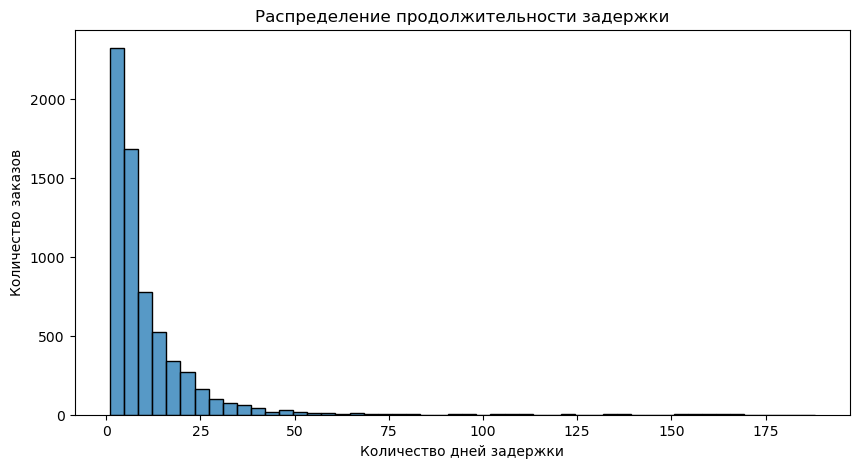

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    data=late_orders,
    x='days_vs_estimate',
    bins=50
)

plt.title('Распределение продолжительности задержки')
plt.xlabel('Количество дней задержки')
plt.ylabel('Количество заказов')
plt.show()

95-й процентиль: 31 день


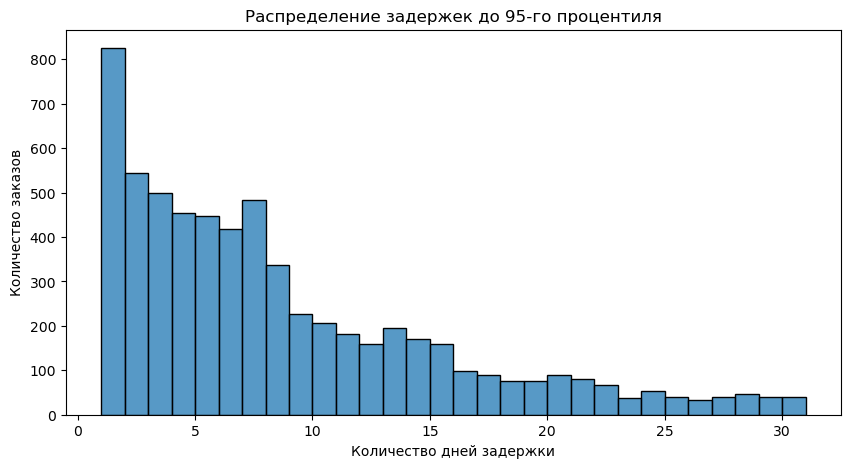

In [50]:
delay_95 = late_orders['days_vs_estimate'].quantile(0.95)

print(f'95-й процентиль: {delay_95:.0f} день')

plt.figure(figsize=(10, 5))

sns.histplot(
    data=late_orders[
        late_orders['days_vs_estimate'] <= delay_95
    ],
    x='days_vs_estimate',
    bins=30
)

plt.title('Распределение задержек до 95-го процентиля')
plt.xlabel('Количество дней задержки')
plt.ylabel('Количество заказов')
plt.show()

### 4.3. Распределение задержек до 95-го процентиля

95% опоздавших заказов были доставлены с задержкой не более 31 дня. Большинство задержек приходится на первые несколько дней, после чего количество заказов постепенно уменьшается.

Для более наглядного отображения основной части распределения на графике не показаны 5% заказов с наиболее длительными задержками. При этом данные заказы не удалялись из исходной выборки и продолжают учитываться в расчётах.


In [51]:
review_score_by_late = (
    delivery_orders
    .groupby('is_late')['review_score']
    .agg(
        orders_count='count',
        mean_score='mean',
        median_score='median'
    )
    .round(2)
)

review_score_by_late

,orders_count,mean_score,median_score
is_late,,,
False,89443,4.29,5.0
True,6381,2.27,1.0


<a id='reviews'></a>

## 5. Опоздания и оценки покупателей

### 5.1. Связь задержки с оценкой заказа

Заказы, доставленные без опоздания, получили в среднем `4,29 балла`, а их медианная оценка составила `5 баллов`. У опоздавших заказов средняя оценка снизилась до `2,27 балла`, а медианная — до `1 балла`.

Таким образом, задержка доставки связана с существенным снижением оценки покупателя. При этом данный результат показывает наличие связи, но не доказывает, что задержка являлась единственной причиной низких оценок.


In [52]:
review_score_distribution = (
    pd.crosstab(
        delivery_orders['is_late'],
        delivery_orders['review_score'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

review_score_distribution

review_score,1.0,2.0,3.0,4.0,5.0
is_late,,,,,
False,6.62,2.65,8.07,20.39,62.27
True,53.77,8.65,10.88,10.17,16.53


### 5.2. Распределение оценок в зависимости от опоздания

Среди заказов, доставленных без опоздания, преобладают высокие оценки: `62,27%` покупателей поставили 5 баллов, а доля оценок в 1 балл составила `6,62%`.

Для опоздавших заказов распределение меняется: `53,77%` таких заказов получили оценку в 1 балл, тогда как доля максимальных оценок снизилась до `16,53%`.

Таким образом, опоздание связано не только со снижением средней оценки, но и с существенным увеличением доли наиболее негативных отзывов.


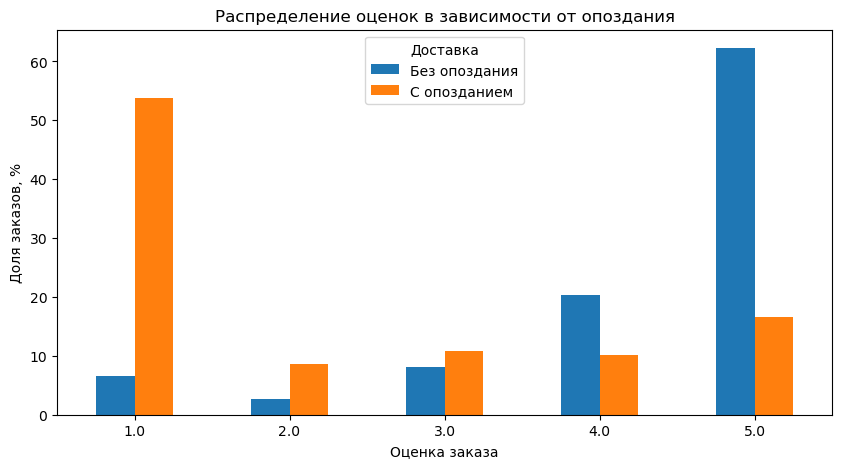

In [53]:
review_score_distribution.T.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Распределение оценок в зависимости от опоздания')
plt.xlabel('Оценка заказа')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.legend(
    ['Без опоздания', 'С опозданием'],
    title='Доставка'
)
plt.show()

График показывает заметное изменение распределения оценок при задержке доставки. Среди заказов без опоздания преобладают максимальные оценки, тогда как среди опоздавших заказов наиболее распространена оценка в 1 балл.

In [54]:
delay_bins = [-float('inf'), 0, 3, 7, 14, 30, float('inf')]

delay_labels = [
    'Без опоздания',
    '1–3 дня',
    '4–7 дней',
    '8–14 дней',
    '15–30 дней',
    'Более 30 дней'
]

delivery_orders['delay_group'] = pd.cut(
    delivery_orders['days_vs_estimate'],
    bins=delay_bins,
    labels=delay_labels
)

score_by_delay = (
    delivery_orders
    .groupby('delay_group', observed=False)
    .agg(
        orders_count=('order_id', 'count'),
        reviews_count=('review_score', 'count'),
        mean_score=('review_score', 'mean')
    )
    .round(2)
)

score_by_delay

,orders_count,reviews_count,mean_score
delay_group,,,
Без опоздания,89936,89443,4.29
1–3 дня,1870,1852,3.29
4–7 дней,1802,1748,2.10
8–14 дней,1478,1446,1.67
15–30 дней,1039,1006,1.61
Более 30 дней,345,329,2.06


### 5.3. Оценка в зависимости от продолжительности задержки

С увеличением продолжительности задержки средняя оценка заказа в целом снижается. Заказы без опоздания получили в среднем `4,29 балла`, при задержке на `1–3 дня` средняя оценка составила `3,29 балла`, а при задержке на `15–30 дней — 1,61 балла`.

В группе с задержкой более `30 дней` средняя оценка немного повысилась до `2,06 балла`. Однако эта группа содержит значительно меньше заказов, поэтому результат следует интерпретировать осторожно.


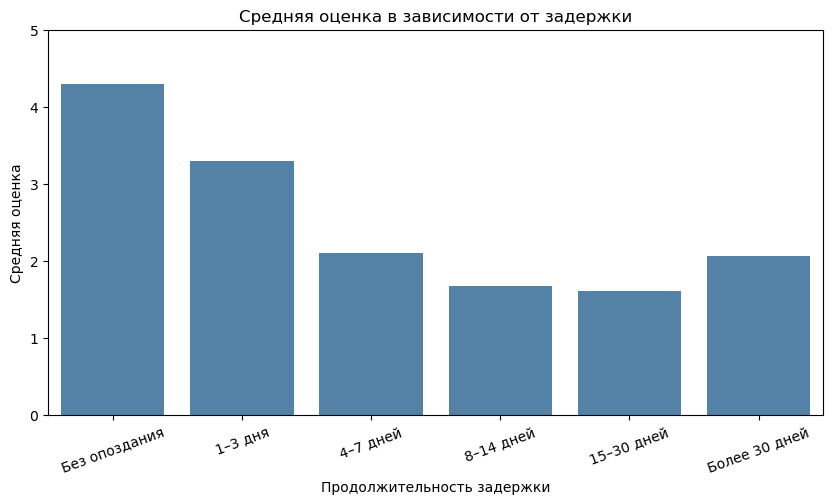

In [55]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=score_by_delay.reset_index(),
    x='delay_group',
    y='mean_score',
    color='steelblue'
)

plt.title('Средняя оценка в зависимости от задержки')
plt.xlabel('Продолжительность задержки')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
plt.xticks(rotation=20)
plt.show()

График подтверждает, что с увеличением продолжительности задержки средняя оценка заказа в целом снижается. Наиболее заметное падение происходит уже при задержке более трёх дней.

Небольшое повышение средней оценки в группе с задержкой более 30 дней не меняет общей тенденции, поскольку эта группа содержит значительно меньше заказов.

In [56]:
late_by_state = (
    delivery_orders
    .groupby('customer_state')
    .agg(
        orders_count=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        mean_score=('review_score', 'mean')
    )
)

late_by_state['late_percent'] = (
    late_by_state['late_orders']
    / late_by_state['orders_count']
    * 100
).round(2)

late_by_state['mean_score'] = (
    late_by_state['mean_score'].round(2)
)

late_by_state = late_by_state.sort_values(
    'late_percent',
    ascending=False
)

late_by_state

,orders_count,late_orders,mean_score,late_percent
customer_state,,,,
AL,397,85,3.85,21.41
MA,717,125,3.83,17.43
SE,335,51,3.91,15.22
PI,476,66,3.99,13.87
CE,1279,176,3.94,13.76
RR,41,5,3.90,12.20
BA,3256,396,3.93,12.16
RJ,12350,1495,3.97,12.11
PA,946,106,3.91,11.21


<a id='factors'></a>

## 6. Факторы и динамика опозданий

### 6.1. Опоздания по штатам покупателей

Доля заказов, доставленных с опозданием, заметно различается между штатами. Наибольшая доля опозданий наблюдается в `AL — 21,41%, MA — 17,43% и SE — 15,22%`.

Наименьшие значения зафиксированы в `AM — 2,76%, RO — 2,88% и AP — 2,99%`. При интерпретации результатов необходимо учитывать количество заказов: в штатах с небольшой выборкой доля опозданий может быть нестабильной.

Средняя оценка также различается по штатам, однако она зависит не только от соблюдения сроков доставки, поэтому связь между этими показателями требует отдельной проверки.


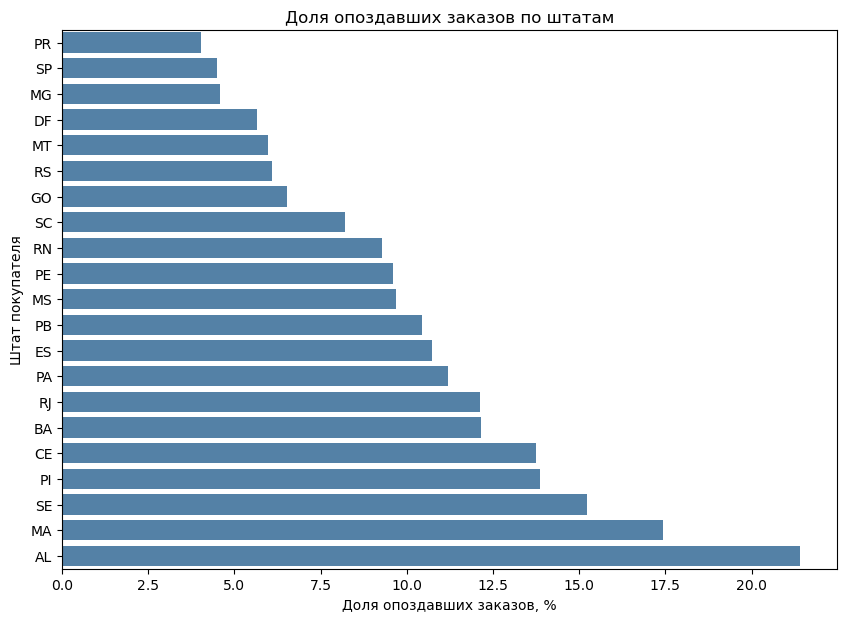

In [57]:
states_for_plot = (
    late_by_state[
        late_by_state['orders_count'] >= 300
    ]
    .sort_values('late_percent', ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=states_for_plot.reset_index(),
    x='late_percent',
    y='customer_state',
    color='steelblue'
)

plt.title('Доля опоздавших заказов по штатам')
plt.xlabel('Доля опоздавших заказов, %')
plt.ylabel('Штат покупателя')
plt.show()

Среди штатов с количеством заказов не менее 300 наибольшая доля опозданий наблюдается в AL, MA и SE. Наименьшие значения среди представленных штатов зафиксированы в PR, SP и MG.

Ограничение по количеству заказов использовалось только при построении графика, чтобы исключить нестабильные показатели небольших групп. Из исходных данных эти штаты не удалялись.

In [59]:
import numpy as np
delivery_orders['seller_group'] = np.where(
    delivery_orders['sellers_count'] == 1,
    '1 продавец',
    '2 и более продавцов'
)

late_by_sellers = (
    delivery_orders
    .groupby('seller_group')
    .agg(
        orders_count=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        late_percent=('is_late', 'mean')
    )
)

late_by_sellers['late_percent'] = (
    late_by_sellers['late_percent'] * 100
).round(2)

late_by_sellers

,orders_count,late_orders,late_percent
seller_group,,,
1 продавец,95195,6521,6.85
2 и более продавцов,1275,13,1.02


### 6.2. Опоздания в зависимости от количества продавцов

Среди заказов с одним продавцом доля опозданий составила `6,85%`, тогда как среди заказов с двумя и более продавцами — `1,02%`.

Таким образом, заказы с несколькими продавцами в рассматриваемых данных опаздывали реже. Однако группа таких заказов значительно меньше, поэтому полученный результат следует интерпретировать осторожно. Кроме того, различие может быть связано с другими характеристиками заказов.


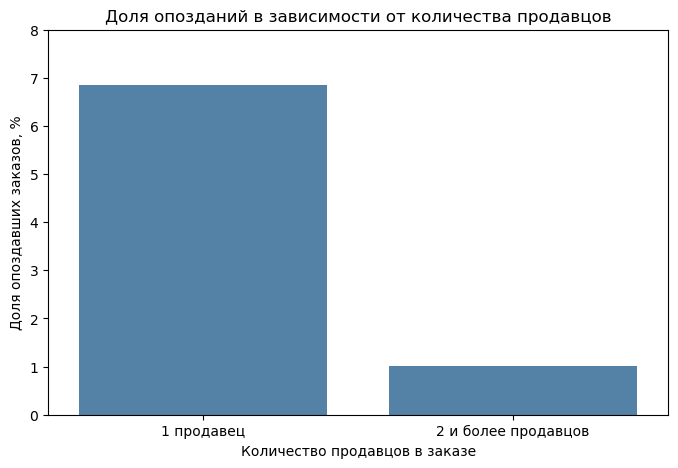

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=late_by_sellers.reset_index(),
    x='seller_group',
    y='late_percent',
    color='steelblue'
)

plt.title('Доля опозданий в зависимости от количества продавцов')
plt.xlabel('Количество продавцов в заказе')
plt.ylabel('Доля опоздавших заказов, %')
plt.ylim(0, 8)
plt.show()

In [61]:
delivery_orders['items_group'] = pd.cut(
    delivery_orders['items_count'],
    bins=[0, 1, 2, float('inf')],
    labels=[
        '1 товар',
        '2 товара',
        '3 и более товаров'
    ],
    include_lowest=True
)

late_by_items = (
    delivery_orders
    .groupby('items_group', observed=False)
    .agg(
        orders_count=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        late_percent=('is_late', 'mean')
    )
)

late_by_items['late_percent'] = (
    late_by_items['late_percent'] * 100
).round(2)

late_by_items

,orders_count,late_orders,late_percent
items_group,,,
1 товар,86835,6024,6.94
2 товара,7392,397,5.37
3 и более товаров,2243,113,5.04


### 6.3. Опоздания в зависимости от количества товаров

Среди заказов с одним товаром доля опозданий составила 6,94%. Для заказов с двумя товарами показатель снизился до `5,37%`, а для заказов с тремя и более товарами — до `5,04%`.

Таким образом, увеличение количества товарных позиций не сопровождалось ростом доли опозданий. Однако группы значительно различаются по количеству заказов, поэтому результат следует интерпретировать осторожно.


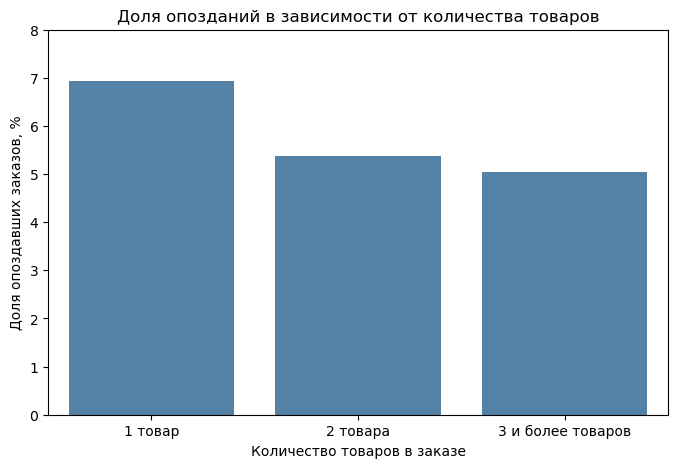

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=late_by_items.reset_index(),
    x='items_group',
    y='late_percent',
    color='steelblue'
)

plt.title('Доля опозданий в зависимости от количества товаров')
plt.xlabel('Количество товаров в заказе')
plt.ylabel('Доля опоздавших заказов, %')
plt.ylim(0, 8)
plt.show()

In [64]:
delivery_orders['purchase_month'] = (
    delivery_orders['order_purchase_timestamp']
    .dt.to_period('M')
    .dt.to_timestamp()
)

late_by_month = (
    delivery_orders
    .groupby('purchase_month')
    .agg(
        orders_count=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        late_percent=('is_late', 'mean')
    )
    .reset_index()
)

late_by_month['late_percent'] = (
    late_by_month['late_percent'] * 100
).round(2)

late_by_month

,purchase_month,orders_count,late_orders,late_percent
0,2016-09-01,1,1,100.00
1,2016-10-01,265,2,0.75
2,2016-12-01,1,0,0.00
3,2017-01-01,750,22,2.93
4,2017-02-01,1653,49,2.96
5,2017-03-01,2546,116,4.56
6,2017-04-01,2303,151,6.56
7,2017-05-01,3545,106,2.99
8,2017-06-01,3135,95,3.03
9,2017-07-01,3872,108,2.79


### 6.4. Изменение доли опозданий по месяцам

Доля опоздавших заказов заметно менялась в течение рассматриваемого периода. Наиболее высокие значения наблюдались в `ноябре 2017 года — 12,40%`, `феврале 2018 года — 14,13%` и `марте 2018 года — 18,96%`.

После пикового значения в марте 2018 года доля опозданий снизилась до 4,50% в апреле и достигла 1,16% в июне.

Данные за сентябрь и декабрь 2016 года не позволяют сделать надёжные выводы, поскольку в каждом из этих месяцев представлен только один заказ.


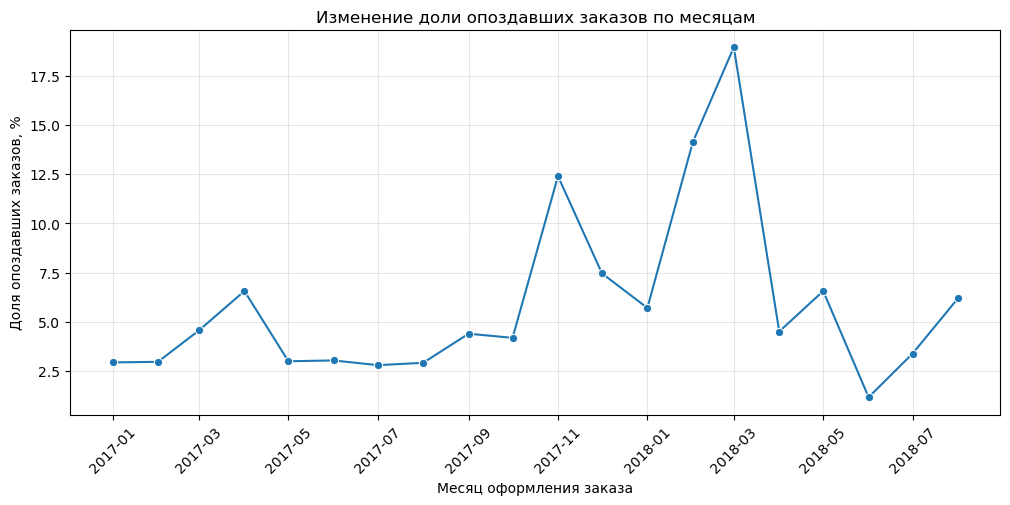

In [65]:
months_for_plot = late_by_month[
    late_by_month['orders_count'] >= 300
].copy()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=months_for_plot,
    x='purchase_month',
    y='late_percent',
    marker='o'
)

plt.title('Изменение доли опоздавших заказов по месяцам')
plt.xlabel('Месяц оформления заказа')
plt.ylabel('Доля опоздавших заказов, %')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

In [66]:
delay_by_month = (
    delivery_orders[
        delivery_orders['is_late']
    ]
    .groupby('purchase_month')
    .agg(
        late_orders=('order_id', 'count'),
        mean_delay=('days_vs_estimate', 'mean'),
        median_delay=('days_vs_estimate', 'median')
    )
    .reset_index()
)

delay_by_month[
    ['mean_delay', 'median_delay']
] = delay_by_month[
    ['mean_delay', 'median_delay']
].round(2)

delay_by_month

,purchase_month,late_orders,mean_delay,median_delay
0,2016-09-01,1,36.00,36.0
1,2016-10-01,2,9.50,9.5
2,2017-01-01,22,20.23,18.5
3,2017-02-01,49,20.80,11.0
4,2017-03-01,116,25.43,8.0
5,2017-04-01,151,12.34,5.0
6,2017-05-01,106,12.54,6.0
7,2017-06-01,95,14.26,7.0
8,2017-07-01,108,11.69,7.0
9,2017-08-01,122,8.79,6.0


### 6.5. Продолжительность опозданий по месяцам

Продолжительность задержек заметно менялась в течение рассматриваемого периода. Среди месяцев с достаточным количеством наблюдений наибольшая средняя задержка зафиксирована в `марте 2017 года — 25,43 дня`. `Медианная задержка` в этом месяце составила `8 дней`, что указывает на наличие отдельных заказов с особенно длительным опозданием.

В `марте 2018 года` наблюдалось `наибольшее количество опоздавших заказов — 1 328`, однако `средняя продолжительность` задержки составила `10,02 дня`. Следовательно, высокая частота опозданий не всегда сопровождалась их наибольшей продолжительностью.

К `августу 2018 года средняя задержка снизилась до 4,42 дня`, а `медианная — до 3 дней`. Данные первых месяцев периода следует интерпретировать осторожно из-за небольшого количества опоздавших заказов.


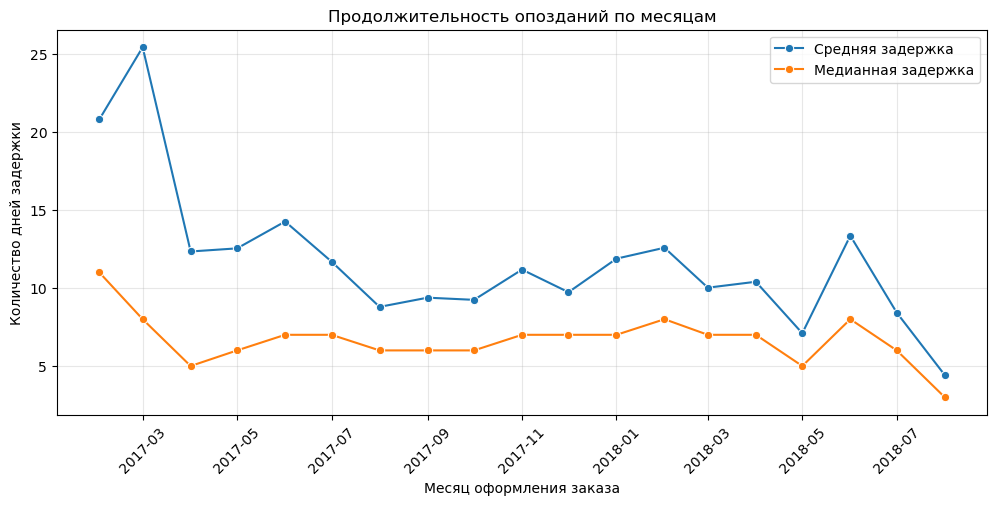

In [67]:
months_delay_for_plot = delay_by_month[
    delay_by_month['late_orders'] >= 30
].copy()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=months_delay_for_plot,
    x='purchase_month',
    y='mean_delay',
    marker='o',
    label='Средняя задержка'
)

sns.lineplot(
    data=months_delay_for_plot,
    x='purchase_month',
    y='median_delay',
    marker='o',
    label='Медианная задержка'
)

plt.title('Продолжительность опозданий по месяцам')
plt.xlabel('Месяц оформления заказа')
plt.ylabel('Количество дней задержки')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

График показывает, что средняя продолжительность задержки в большинстве месяцев превышала медианную. Это связано с наличием отдельных заказов с особенно длительными опозданиями.

Наибольший разрыв между показателями наблюдался в марте 2017 года: средняя задержка составила 25,43 дня, а медианная — 8 дней. В дальнейшем продолжительность опозданий в целом снижалась, и к августу 2018 года средняя задержка сократилась до 4,42 дня, а медианная — до 3 дней.

На графике представлены только месяцы, в которых было не менее 30 опоздавших заказов. Из исходных данных остальные месяцы не удалялись.

In [68]:
monthly_late_metrics = (
    late_by_month
    .merge(
        delay_by_month,
        on='purchase_month',
        how='left'
    )
)

monthly_late_metrics_for_analysis = (
    monthly_late_metrics[
        (monthly_late_metrics['orders_count'] >= 300)
        & (monthly_late_metrics['late_orders_y'] >= 30)
    ]
    .copy()
)

late_delay_correlation = (
    monthly_late_metrics_for_analysis[
        ['late_percent', 'mean_delay']
    ]
    .corr()
    .loc['late_percent', 'mean_delay']
)

print(
    f'Корреляция между долей и средней '
    f'продолжительностью опозданий: '
    f'{late_delay_correlation:.2f}'
)

Корреляция между долей и средней продолжительностью опозданий: -0.16


<a id='correlation'></a>

## 7. Связь частоты и продолжительности опозданий

### 7.1. Корреляция Пирсона

`Коэффициент корреляции между долей опоздавших заказов и средней продолжительностью задержки составил −0,16`. Это указывает на очень слабую отрицательную линейную связь между показателями.

Таким образом, месяцы с более высокой долей опозданий не обязательно сопровождались более продолжительными задержками. Частота и длительность опозданий отражают разные характеристики качества доставки.

При интерпретации результата необходимо учитывать, что расчёт выполнен по ограниченному количеству месяцев, а корреляция показывает только линейную связь и не свидетельствует о причинно-следственной зависимости.


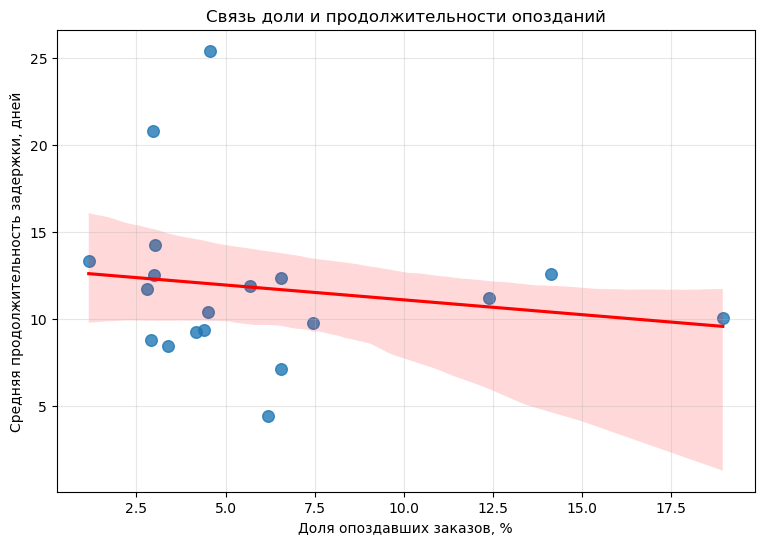

In [69]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=monthly_late_metrics_for_analysis,
    x='late_percent',
    y='mean_delay',
    scatter_kws={
        's': 70,
        'alpha': 0.8
    },
    line_kws={
        'color': 'red'
    }
)

plt.title('Связь доли и продолжительности опозданий')
plt.xlabel('Доля опоздавших заказов, %')
plt.ylabel('Средняя продолжительность задержки, дней')
plt.grid(alpha=0.3)
plt.show()

График не показывает выраженной зависимости между частотой и продолжительностью опозданий. Линия регрессии имеет небольшой отрицательный наклон, однако точки сильно разбросаны, а доверительный интервал достаточно широк.

Это подтверждает, что месяцы с высокой долей опоздавших заказов не обязательно характеризовались более длительными задержками. Частоту и продолжительность опозданий следует рассматривать как разные показатели качества доставки.

In [70]:
spearman_correlation = (
    monthly_late_metrics_for_analysis[
        ['late_percent', 'mean_delay']
    ]
    .corr(method='spearman')
    .loc['late_percent', 'mean_delay']
)

print(
    f'Корреляция Спирмена между долей и средней '
    f'продолжительностью опозданий: '
    f'{spearman_correlation:.2f}'
)

Корреляция Спирмена между долей и средней продолжительностью опозданий: -0.20


### 7.2. Дополнительная проверка: корреляция Спирмена

Коэффициент корреляции Спирмена составил −0,20. Значение близко к нулю и указывает на отсутствие заметной монотонной связи между долей опоздавших заказов и средней продолжительностью задержки.

Результат согласуется с коэффициентом корреляции Пирсона, равным −0,16. Следовательно, месяцы с более частыми опозданиями не обязательно характеризовались большей продолжительностью задержек.


In [71]:
from scipy.stats import pearsonr, spearmanr

x = monthly_late_metrics_for_analysis['late_percent']
y = monthly_late_metrics_for_analysis['mean_delay']

pearson_corr, pearson_pvalue = pearsonr(x, y)
spearman_corr, spearman_pvalue = spearmanr(x, y)

print(f'Количество месяцев: {len(x)}')
print(
    f'Корреляция Пирсона: {pearson_corr:.2f}, '
    f'p-value: {pearson_pvalue:.3f}'
)
print(
    f'Корреляция Спирмена: {spearman_corr:.2f}, '
    f'p-value: {spearman_pvalue:.3f}'
)

Количество месяцев: 19
Корреляция Пирсона: -0.16, p-value: 0.503
Корреляция Спирмена: -0.20, p-value: 0.414


### 7.3. Статистическая значимость связи

Для проверки статистической значимости были рассчитаны коэффициенты корреляции Пирсона и Спирмена вместе с соответствующими p-value.

Коэффициент корреляции Пирсона составил −0,16 при p-value, равном 0,503. Коэффициент корреляции Спирмена составил −0,20 при p-value, равном 0,414.

Оба значения p-value превышают уровень значимости 0,05. Следовательно, статистически значимая связь между долей опоздавших заказов и средней продолжительностью задержки не обнаружена.

Результат следует интерпретировать осторожно, поскольку расчёт выполнен только по 19 месяцам. Отсутствие статистической значимости не доказывает полного отсутствия связи, но имеющихся данных недостаточно, чтобы уверенно отличить её от случайных колебаний.


<a id='conclusions'></a>

## 8. Общие выводы и рекомендации

В ходе исследования была проанализирована своевременность доставки заказов, продолжительность задержек и их связь с оценками покупателей.

### Основные выводы

1. Опоздание доставки связано со снижением оценки заказа. Чем продолжительнее задержка, тем ниже в среднем оценка покупателя. Наиболее заметное падение наблюдается уже при задержке более трёх дней.

2. Доля опозданий заметно различается между штатами. Наиболее высокие показатели наблюдались в AL, MA и SE. При сравнении регионов необходимо учитывать количество заказов, поскольку показатели небольших групп могут быть нестабильными.

3. Заказы с одним продавцом опаздывали чаще, чем заказы с двумя и более продавцами: 6,85% против 1,02%. Однако группа заказов с несколькими продавцами значительно меньше, поэтому этот результат требует осторожной интерпретации.

4. Увеличение количества товаров в заказе не сопровождалось ростом доли опозданий. Для заказов с одним товаром показатель составил 6,94%, с двумя товарами — 5,37%, а с тремя и более — 5,04%.

5. Доля опозданий существенно менялась во времени. Наибольшее значение зафиксировано в марте 2018 года — 18,96%. Повышенные показатели также наблюдались в ноябре 2017 года и феврале 2018 года. После марта 2018 года доля опозданий заметно снизилась.

6. Частота и продолжительность опозданий отражают разные характеристики доставки. В марте 2018 года наблюдалось наибольшее количество опозданий, но наиболее продолжительные задержки среди месяцев с достаточным количеством наблюдений были зафиксированы в марте 2017 года.

7. Статистически значимая связь между долей опозданий и их средней продолжительностью по месяцам не обнаружена. Коэффициент Пирсона составил −0,16 при p-value 0,503, а коэффициент Спирмена — −0,20 при p-value 0,414.

### Рекомендации

- Отдельно контролировать долю опоздавших заказов и продолжительность задержек, поскольку высокая частота опозданий не всегда означает их большую длительность.
- Особое внимание уделить штатам с высокой долей опозданий и достаточным количеством заказов, прежде всего AL, MA и SE.
- Дополнительно исследовать причины пиков опозданий в ноябре 2017 года, феврале и марте 2018 года.
- Реагировать на задержки как можно раньше, поскольку уже после трёх дней опоздания наблюдается заметное снижение оценки покупателей.
- При оценке качества доставки использовать не только среднюю, но и медианную продолжительность задержки, так как отдельные очень длительные опоздания могут значительно завышать среднее значение.
- Не интерпретировать различия по количеству продавцов и товаров как причинно-следственные без дополнительного статистического анализа и учёта других характеристик заказа.

Таким образом, соблюдение предполагаемого срока доставки является важным фактором удовлетворённости покупателей. Для улучшения качества сервиса необходимо одновременно снижать частоту опозданий и предотвращать отдельные продолжительные задержки.